In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [18]:
# Constants
AU = 149597870 #km
MU_SUN = 1.32712440041279419e11 # km3/s2
MU_EARTH = 398600 # km3/s2

EARTH_Q = 9.78969676e-01 * AU # km
EARTH_E = 1.83889630e-02
EARTH_A = EARTH_Q / (1 - EARTH_E)
EARTH_I = 7.55697209e-05 # rad
EARTH_ARGP = 5.34322623 # rad
EARTH_RAAN = 2.63906227 # rad
EARTH_M = 1.88972281 # rad
EARTH_PER = np.sqrt(4 * np.pi**2 * EARTH_A**3 / MU_SUN)
EARTH_N = 2 * np.pi / EARTH_PER

FI2026_Q = 0.74161536 * AU # km
FI2026_E = 0.19293483
FI2026_A = FI2026_Q / (1 - FI2026_E)
FI2026_I = 0.05877868 # rad
FI2026_ARGP = 2.22509624 # rad
FI2026_RAAN = 3.55784498 # rad
FI2026_M = 3.64624167 # rad
FI2026_PER = np.sqrt(4 * np.pi**2 * FI2026_A**3 / MU_SUN)
FI2026_N = 2 * np.pi / FI2026_PER

EARTH_KEP = np.array([EARTH_A, EARTH_E, EARTH_I, EARTH_ARGP, EARTH_RAAN, EARTH_M])
FI2026_KEP = np.array([FI2026_A, FI2026_E, FI2026_I, FI2026_ARGP, FI2026_RAAN, FI2026_M])

In [35]:
#Newton's method applied to find eccentric anomaly
def find_E(M, e):
    E_prev = M
    E_curr = E_prev - (E_prev - e * np.sin(E_prev) - M) / (1 - e * np.cos(E_prev))
    while (abs(E_curr - E_prev) > 1E-10):
        E_prev = E_curr
        E_curr = E_prev - (E_prev - e * np.sin(E_prev) - M) / (1 - e * np.cos(E_prev))
    return E_curr

#Elements to vectors calculator
def elems_to_vecs(kep_state, mu):
    """
    Converts classical orbital elements to position and velocity vectors.
    Inputs:
        a   : Semi-major axis (float)
        e   : Eccentricity (float)
        i   : Inclination (float, radians)
        ran : Right ascension of ascending node (float, radians)
        arg : Argument of periapsis (float, radians)
        M   : Mean anomaly (float, radians)
        mu  : Gravitational parameter of the central body (float)
    Outputs:
        r : Position vector (numpy array)
        v : Velocity vector (numpy array)
    """
    
    a, e, i, arg, ran, m = kep_state
    
    #Find eccentric anomaly and convert to true
    E = find_E(m, e)
    f = 2*np.arctan2(np.sqrt(1+e)*np.sin(E/2), np.sqrt(1-e)*np.cos(E/2))
    theta = arg + f
    
    #Solve for angular momentum and r_mag
    h = (mu * a * (1 - e**2))**(1/2)
    r_mag = (a * (1 - e**2)) / (1 + e * np.cos(f))
    
    #I, J, K vecs
    I = np.array([1, 0, 0])
    J = np.array([0, 1, 0])
    K = np.array([0, 0, 1])
    
    #Solve for r
    ehat_r = ((np.cos(theta) * np.cos(ran) - np.cos(i) * np.sin(ran) * np.sin(theta)) * I +
              (np.cos(theta) *np.sin(ran) + np.cos(i) * np.cos(ran) * np.sin(theta)) * J +
              (np.sin(i) * np.sin(theta)) * K)
    r = r_mag * ehat_r
    
    #Solve for v
    v = (-mu / h * (np.cos(ran) * (np.sin(theta) + e * np.sin(arg)) + np.sin(ran) * (np.cos(theta) + e * np.cos(arg)) * np.cos(i)) * I +
         -mu / h * (np.sin(ran) * (np.sin(theta) + e * np.sin(arg)) - np.cos(ran) * (np.cos(theta) + e * np.cos(arg)) * np.cos(i)) * J +
         mu / h * (np.cos(theta) + e * np.cos(arg)) * np.sin(i) * K)
    v_mag = np.sqrt(v.dot(v))
    
    return np.array([r[0], r[1], r[2], v[0], v[1], v[2]])

# Old AE402 Function I am reusing
def vecs_to_elems(r, v, mu):
    """
    Converts position and velocity vectors to classical orbital elements.
    Inputs:
        r : Position vector (numpy array)
        v : Velocity vector (numpy array)
        mu: Gravitational parameter of the central body (float)
    Outputs:
        a   : Semi-major axis (float)
        e   : Eccentricity (float)
        i   : Inclination (float, radians)
        ran : Right ascension of ascending node (float, radians)
        arg : Argument of periapsis (float, radians)
        f   : True anomaly (float, radians)
    """
    #Solve for various values to be used
    r_mag = np.linalg.norm(r)
    v_mag =np.linalg.norm(v)
    h = np.cross(r, v)
    h_mag = np.linalg.norm(h)
    I = np.array([1, 0, 0])
    J = np.array([0, 1, 0])
    K = np.array([0, 0, 1])
    n = np.cross(K, h)
    n_mag = np.linalg.norm(n)
    
    #Get a, e, i
    a = 1 / (2 / r_mag - v_mag**2 / mu)
    e = (v_mag**2 / mu - 1 / r_mag) * r - 1 / mu * (r.dot(v)) * v
    e_mag = np.linalg.norm(e)
    i = np.acos((h / h_mag).dot(K))
    
    #Get ran, arg, f
    ran = np.acos(n.dot(I) / n_mag)
    if n.dot(J) < 0:
        ran = 2 * np.pi - ran
    arg = np.acos(n.dot(e) / (n_mag * e_mag))
    if e.dot(K) < 0:
        arg = 2 * np.pi - arg
    f = np.acos(r.dot(e) / (r_mag * e_mag))
    if r.dot(v) < 0:
        f = 2 * np.pi - f
        
    E = 2 * np.arctan2(np.sqrt(1 - e_mag) * np.sin(f / 2), np.sqrt(1 + e_mag) * np.cos(f / 2))
    M = E - e_mag * np.sin(E)
            
    return np.array([a, e_mag, i, arg, ran, M])

def gauss_state_deriv(kep_state, a_dr, a_dt, a_dh, dt):
    """
    Returns the step of keplerian states 
    Inputs:
        kep_state : a, e, i, argp, raan, m (km, unitless, rad, rad, rad, rad)
        a_dr : perturbing radial acceleration (km/s2)
        a_dt : perturbing tangential acceleration (km/s2)
        a_dh : perturbing normal acceleration (km/s2)
        dt : time step (s)
    Outputs:
        kep_state_deriv
    """
    a, e, i, argp, raan, m = kep_state
    
    # Various needed values
    E = find_E(m, e)
    f = np.arctan2(np.sqrt(1 - e**2) * np.sin(E), np.cos(E) - e)
    theta = argp + f
    p = a * (1 - e**2)
    r = p / (1 + e * np.cos(f))
    h = np.sqrt(MU_SUN * p)
    b = np.sqrt(p / a)
    per = np.sqrt(4 * np.pi**2 * a**3 / MU_SUN)
    n = 2 * np.pi / per
    
    d_raan = r * np.sin(theta) / (h * np.sin(i)) * a_dh
    d_i = r * np.cos(theta) / h * a_dh
    d_argp = 1 / (h * e) * (-p * np.cos(f) * a_dr + (p + r) * np.sin(f) * a_dt) - r * np.sin(theta) * np.cos(i) / (h * np.sin(i)) * a_dh
    d_a = 2 * a**2 / h * (e * np.sin(f) * a_dr + p / r * a_dt)
    d_e = 1 / h * (p * np.sin(f) * a_dr + (p + r) * np.cos(f) * a_dt)
    d_m = n + b / (a * h * e) * ((p * np.cos(f) - 2 * r * e) * a_dr - (p + r) * np.sin(f) * a_dt)
        
    return np.array([d_a, d_e, d_i, d_argp, d_raan, d_m])

def gauss_rk4_step(earth_state, body_state, a_arr, rv_earth, rv_body, dt):
    """
    Complets a step of gaussian planetary propagation in rk4
    Inputs:
        earth_state : keplerian params a, e, i, argp, raan, m
        body_state : keplerian params a, e, i, argp, raan, m
        rv_earth : position and velocity of earth
        rv_body : position and velocity of body
        a_arr : np array of accelerations [a_dr, a_dh, a_dt]
    """
    
    k1 = gauss_state_deriv(earth_state, 0, 0, 0, dt)
    k2 = gauss_state_deriv(earth_state + 0.5 * dt * k1, 0, 0, 0, dt)
    k3 = gauss_state_deriv(earth_state + 0.5 * dt * k2, 0, 0, 0, dt)
    k4 = gauss_state_deriv(earth_state + dt * k3, 0, 0, 0, dt)
    next_earth = earth_state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    a_dr, a_dh, a_dt = a_arr[0], a_arr[1], a_arr[2]
    # --------- Second body perturbation calculation (no longer need per class instructions) ------
    # r_body = rv_body[0:3]
    # v_body = rv_body[3:6]
    # r_body_to_earth = rv_earth[0:3] - rv_body[0:3]
    # rad = r_body / np.linalg.norm(r_body)
    # out = np.cross(r_body, v_body) / np.linalg.norm(np.cross(r_body, v_body))
    # tan = np.cross(out, rad) / np.linalg.norm(np.cross(out, rad))
    # a_second_body = MU_EARTH * r_body_to_earth / np.linalg.norm(r_body_to_earth)**3
    
    # a_dr += np.dot(a_second_body, rad)
    # a_dt += np.dot(a_second_body, tan)
    # a_dh += np.dot(a_second_body, out)
        
    k1 = gauss_state_deriv(body_state, a_dr, a_dt, a_dh, dt)
    k2 = gauss_state_deriv(body_state + 0.5 * dt * k1, a_dr, a_dt, a_dh, dt)
    k3 = gauss_state_deriv(body_state + 0.5 * dt * k2, a_dr, a_dt, a_dh, dt)
    k4 = gauss_state_deriv(body_state + dt * k3, a_dr, a_dt, a_dh, dt)
    next_body = body_state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    return next_earth, next_body

def gauss_rk4_propagate(earth_state0, body_state0, a_arr, t0, tf, dt):
    n_steps = int(np.ceil((tf - t0) / dt))
    t = t0
    
    earth_state = earth_state0.copy()
    rv_earth = elems_to_vecs(earth_state, MU_SUN)

    body_state = body_state0.copy()
    rv_body = elems_to_vecs(body_state, MU_SUN)

    time_list  = [t]
    earth_state_list = [earth_state.copy()]
    body_state_list = [body_state.copy()]
    earth_rv_list = [rv_earth]
    body_rv_list = [rv_body]
    second_body_list = []

    # I asked ChatGPT to help me make a progress bar, that is why this looks a bit weird
    for _ in tqdm(range(n_steps), desc="Propagating"):
        
        # Adjust final step to land exactly on tf
        step = min(dt, tf - t)
        if step <= 0:
            break
        
        earth_state, body_state = gauss_rk4_step(earth_state, body_state, a_arr, rv_earth, rv_body, step)
        rv_earth = elems_to_vecs(earth_state, MU_SUN)
        rv_body = elems_to_vecs(body_state, MU_SUN)
        
        t += step

        time_list.append(t)
        
        earth_state_list.append(earth_state.copy())
        body_state_list.append(body_state)
        earth_rv_list.append(rv_earth)
        body_rv_list.append(rv_body)

    return np.array(time_list), np.array(earth_state_list), np.array(body_state_list), np.array(earth_rv_list), np.array(body_rv_list)

Propagating:   0%|          | 0/34560 [00:00<?, ?it/s]

Time of Collision: 360.0 days


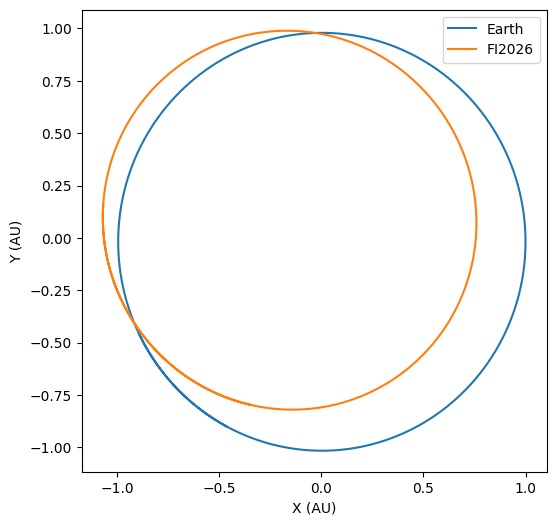

In [39]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

a_arr = np.array([0, 0, 0])

TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP, a_arr, t0, tf, dt)

R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
plt.figure(figsize = (6, 6))
plt.plot(EARTH_RV_LIST[:,0] / AU, EARTH_RV_LIST[:,1] / AU, label = "Earth")
plt.plot(FI2026_RV_LIST[:,0] / AU, FI2026_RV_LIST[:,1] / AU, label = "FI2026")
plt.xlabel("X (AU)")
plt.ylabel("Y (AU)")
plt.legend()

R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)

collision_idx = np.argmin(R_DIFF_MAG_LIST)
min_time = TIME_LIST[collision_idx]
print(f"Time of Collision: {min_time / 3600 / 24} days")

In [37]:
from matplotlib.patches import Circle

def plot_bplane(earth_vel, rel_pos, rel_vel, title = "", valsecchi_ratios = []):
    """
    Plot b plane with impact location and gravitational focusing of Earth
    Inputs
        earth_vel - 1d np array
        rel_vel - 1d np array
        rel_pos - 1d np array
        body kep - state array a, e, i, argp, raan, i
        title - title of the graph
        valsecchi_rations - resonance ratios T_body / T_planet
    """
    R_E = 6378 # km
    MU_E = 398600 # km3/s2
    s_hat = rel_vel / np.linalg.norm(rel_vel)
    xi_hat = np.cross(earth_vel, s_hat) / np.linalg.norm(np.cross(earth_vel, s_hat))
    zeta_hat = np.cross(-s_hat, xi_hat)
    h = np.cross(rel_pos, rel_vel)
    b = np.cross(s_hat, h) / np.linalg.norm(rel_vel)
    xi = np.dot(b, xi_hat)
    zeta = np.dot(b, zeta_hat)
    b_max = R_E * np.sqrt(1 + 2 * MU_E / (R_E * np.linalg.norm(rel_vel)**2))
    
    fig, ax = plt.subplots(figsize = (8, 6))
    
    U_kms = np.linalg.norm(rel_vel)
    c = MU_E / U_kms**2
    theta = np.acos(np.dot(rel_vel, earth_vel) / np.linalg.norm(rel_vel) / np.linalg.norm(earth_vel))

    color_list = ['red', 'green', 'brown', 'indigo', 'violet']
    
    for i, vr in enumerate(valsecchi_ratios):
        
        U = np.linalg.norm(rel_vel) / np.linalg.norm(earth_vel)
        ap_body = (vr)**(2 / 3)
        theta_p = np.acos((1 - U**2 - 1 / ap_body) / (2 * U))
        
        D = (c * np.sin(theta)) / (np.cos(theta_p) - np.cos(theta))
        R = abs((c * np.sin(theta_p)) / (np.cos(theta_p) - np.cos(theta)))
        
        vc = Circle((0, D / R_E), R / R_E, label = f'VC {vr:.3f}', color = color_list[i], fill = False)
        ax.add_patch(vc)
        
        
    earth = Circle((0, 0), R_E / R_E, color = 'blue', fill = False, label = "Earth")
    earth_focused = Circle((0, 0), b_max / R_E, color = 'grey', fill = False, label = "Earth Focused")
    ax.add_patch(earth)
    ax.add_patch(earth_focused)
    ax.scatter(zeta / R_E, xi / R_E, s = 30, color = 'orange', label = "FI2026")
    ax.set_xlabel(r"$\zeta$ (Earth Radii)")
    ax.set_ylabel(r"$\xi$ (Earth Radii)")
    ax.set_title(title)
    ax.legend()
    ax.plot()


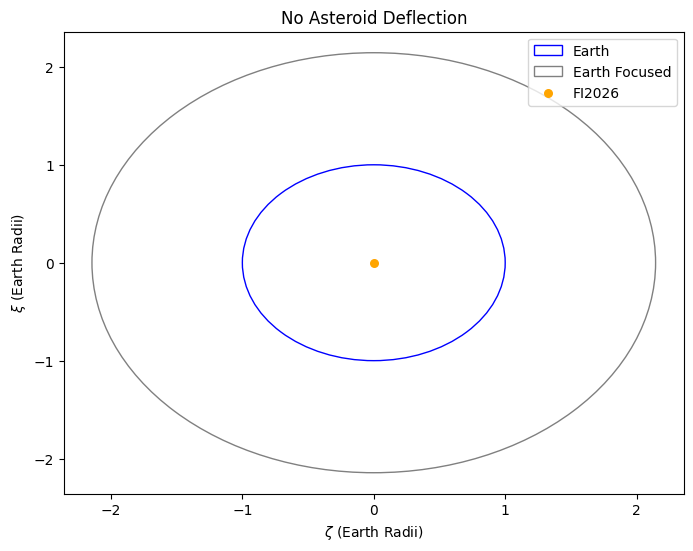

In [38]:
# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel

plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, title = rf"No Asteroid Deflection")


In [22]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

# a_dr, a_dh, a_dt
a_arr = np.array([1e-10, 0, 0])

TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP, a_arr, t0, tf, dt)

# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel



Propagating:   0%|          | 0/34560 [00:00<?, ?it/s]

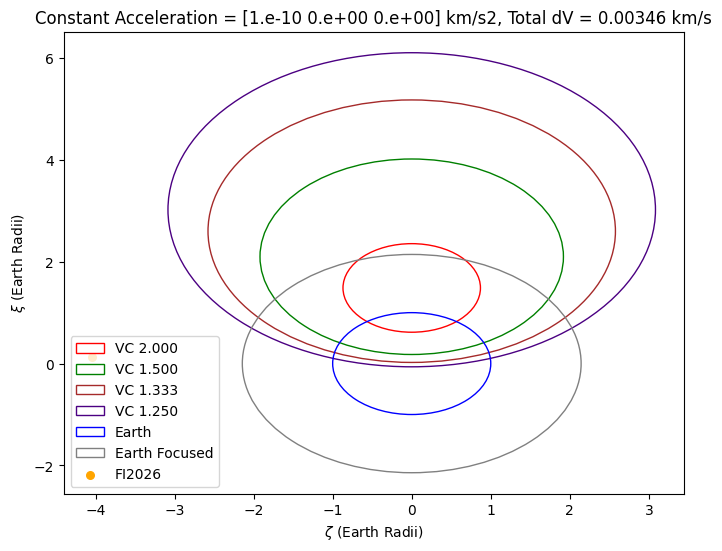

In [23]:
vc_arr = np.array([2 / 1, 3 / 2, 4 / 3, 5 / 4])
plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, valsecchi_ratios = vc_arr, title = rf"Constant Acceleration = {a_arr} km/s2, Total dV = {round(np.linalg.norm(a_arr) * tf, 5)} km/s")


In [24]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

# a_dr, a_dh, a_dt
a_arr = np.array([0, 8e-10, 0])

TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP, a_arr, t0, tf, dt)

# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel

Propagating:   0%|          | 0/34560 [00:00<?, ?it/s]

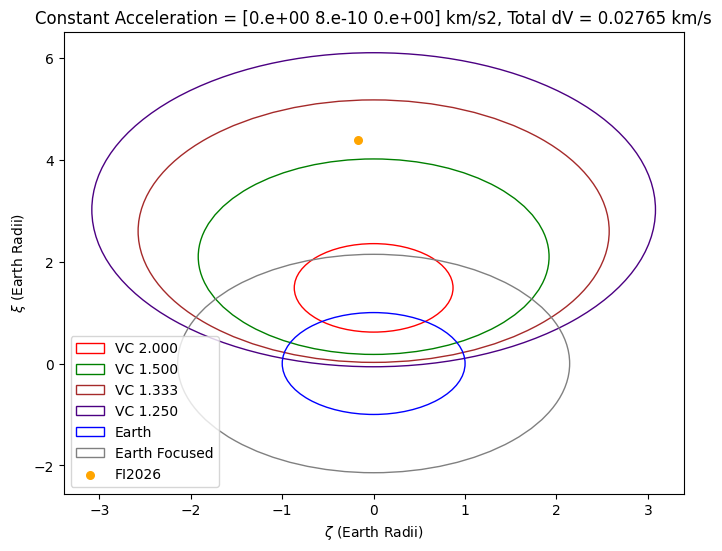

In [25]:
vc_arr = np.array([2 / 1, 3 / 2, 4 / 3, 5 / 4])
plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, valsecchi_ratios = vc_arr, title = f"Constant Acceleration = {a_arr} km/s2, Total dV = {round(np.linalg.norm(a_arr) * tf, 5)} km/s")

In [26]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

# a_dr, a_dh, a_dt
a_arr = np.array([0, 0, 2e-11])

TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP, a_arr, t0, tf, dt)

# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel

Propagating:   0%|          | 0/34560 [00:00<?, ?it/s]

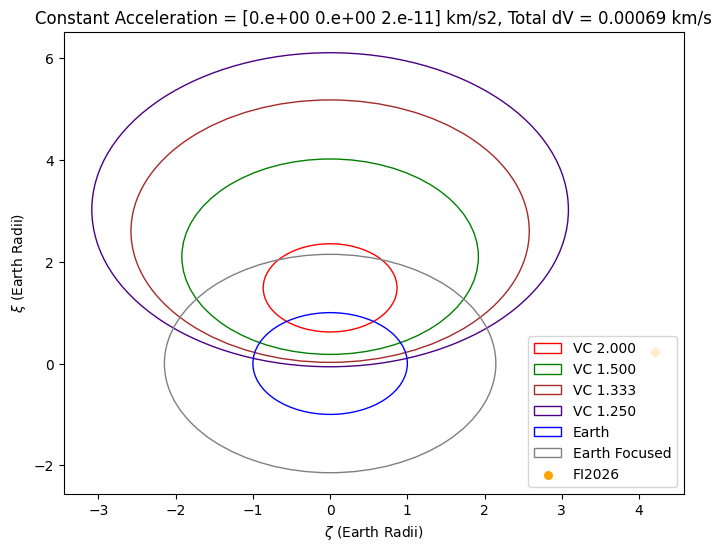

In [27]:
vc_arr = np.array([2 / 1, 3 / 2, 4 / 3, 5 / 4])
plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, valsecchi_ratios = vc_arr, title = f"Constant Acceleration = {a_arr} km/s2, Total dV = {round(np.linalg.norm(a_arr) * tf, 5)} km/s")

In [ ]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

a_arr = np.array([0, 0, 0])
dv_arr = np.array([0.01, 0, 0])
FI2026_STATE = elems_to_vecs(FI2026_KEP, MU_SUN)

# solve for radial, out of plane, and tangential, dv_dr, dv_dh, dv_dt
r_body = FI2026_STATE[0:3]
v_body = FI2026_STATE[3:6]
rad = r_body / np.linalg.norm(r_body)
out = np.cross(r_body, v_body) / np.linalg.norm(np.cross(r_body, v_body))
tan = np.cross(out, rad) / np.linalg.norm(np.cross(out, rad))
dv_arr_xyz = dv_arr[0] * rad + dv_arr[1] * out + dv_arr[2] * tan

FI2026_STATE[3:6] = FI2026_STATE[3:6] + dv_arr_xyz

FI2026_KEP_IMPACT = vecs_to_elems(FI2026_STATE[0:3], FI2026_STATE[3:6], MU_SUN)
TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP_IMPACT, a_arr, t0, tf, dt)

# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel

Propagating:   0%|          | 0/172800 [00:00<?, ?it/s]

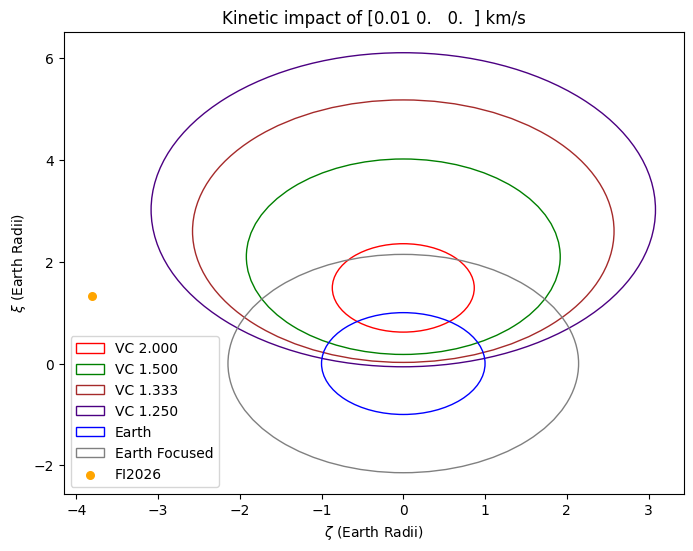

In [46]:
vc_arr = np.array([2 / 1, 3 / 2, 4 / 3, 5 / 4])
plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, valsecchi_ratios = vc_arr, title = f"Kinetic impact of {dv_arr} km/s")

In [30]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

a_arr = np.array([0, 0, 0])
dv_arr = np.array([0, 0.01, 0])
FI2026_STATE = elems_to_vecs(FI2026_KEP, MU_SUN)

# solve for radial, out of plane, and tangential, dv_dr, dv_dh, dv_dt
r_body = FI2026_STATE[0:3]
v_body = FI2026_STATE[3:6]
rad = r_body / np.linalg.norm(r_body)
out = np.cross(r_body, v_body) / np.linalg.norm(np.cross(r_body, v_body))
tan = np.cross(out, rad) / np.linalg.norm(np.cross(out, rad))
dv_arr_xyz = dv_arr[0] * rad + dv_arr[1] * out + dv_arr[2] * tan

FI2026_STATE[3:6] = FI2026_STATE[3:6] + dv_arr_xyz

FI2026_KEP_IMPACT = vecs_to_elems(FI2026_STATE[0:3], FI2026_STATE[3:6], MU_SUN)
TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP_IMPACT, a_arr, t0, tf, dt)

# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel

Propagating:   0%|          | 0/34560 [00:00<?, ?it/s]

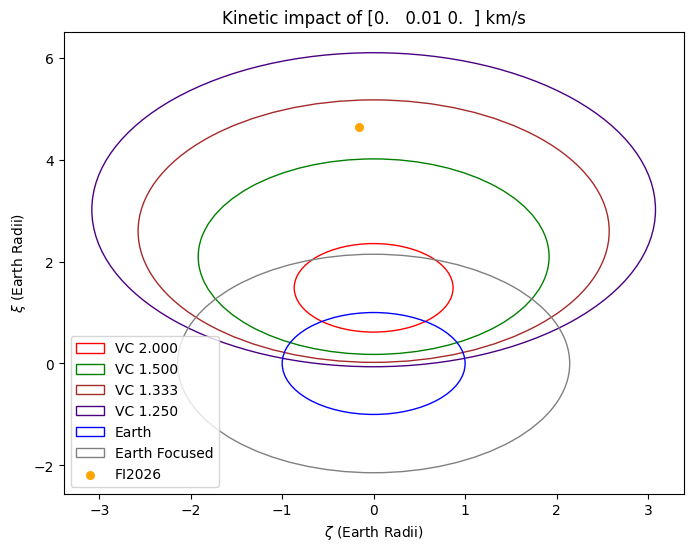

In [31]:
vc_arr = np.array([2 / 1, 3 / 2, 4 / 3, 5 / 4])
plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, valsecchi_ratios = vc_arr, title = f"Kinetic impact of {dv_arr} km/s")

In [32]:
t0 = 0
tf = 3600 * 24 * 400
dt = 1000

a_arr = np.array([0, 0, 0])
dv_arr = np.array([0, 0, 0.0005])
FI2026_STATE = elems_to_vecs(FI2026_KEP, MU_SUN)

# solve for radial, out of plane, and tangential, dv_dr, dv_dh, dv_dt
r_body = FI2026_STATE[0:3]
v_body = FI2026_STATE[3:6]
rad = r_body / np.linalg.norm(r_body)
out = np.cross(r_body, v_body) / np.linalg.norm(np.cross(r_body, v_body))
tan = np.cross(out, rad) / np.linalg.norm(np.cross(out, rad))
dv_arr_xyz = dv_arr[0] * rad + dv_arr[1] * out + dv_arr[2] * tan

FI2026_STATE[3:6] = FI2026_STATE[3:6] + dv_arr_xyz

FI2026_KEP_IMPACT = vecs_to_elems(FI2026_STATE[0:3], FI2026_STATE[3:6], MU_SUN)
TIME_LIST, EARTH_STATE_LIST, FI2026_STATE_LIST, EARTH_RV_LIST, FI2026_RV_LIST = gauss_rk4_propagate(EARTH_KEP, FI2026_KEP_IMPACT, a_arr, t0, tf, dt)

# Find collision index
R_DIFF_LIST = EARTH_RV_LIST - FI2026_RV_LIST
R_DIFF_MAG_LIST = np.linalg.norm(R_DIFF_LIST, axis = 1)
collision_idx = np.argmin(R_DIFF_MAG_LIST)

collision_earth_pos = EARTH_RV_LIST[collision_idx][0:3]
collision_fi2026_pos = FI2026_RV_LIST[collision_idx][0:3]
collision_rel_pos = collision_fi2026_pos - collision_earth_pos

collision_earth_vel = EARTH_RV_LIST[collision_idx][3:6]
collision_fi2026_vel = FI2026_RV_LIST[collision_idx][3:6]
collision_rel_vel = collision_fi2026_vel - collision_earth_vel

Propagating:   0%|          | 0/34560 [00:00<?, ?it/s]

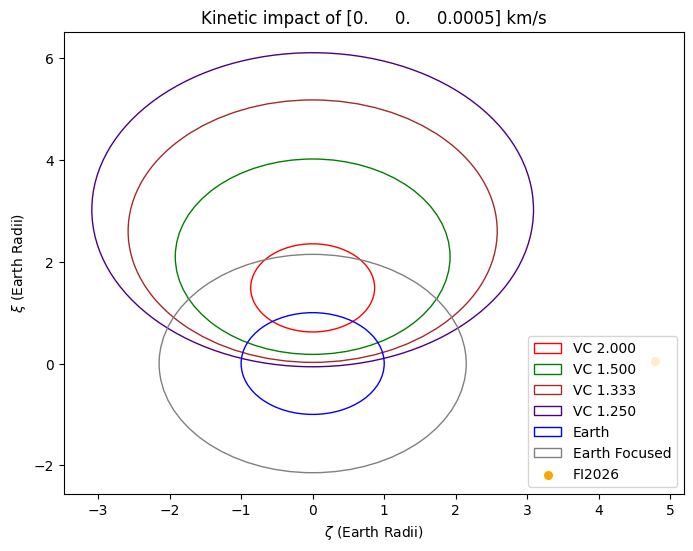

In [33]:
vc_arr = np.array([2 / 1, 3 / 2, 4 / 3, 5 / 4])
plot_bplane(collision_earth_vel, collision_rel_pos, collision_rel_vel, valsecchi_ratios = vc_arr, title = f"Kinetic impact of {dv_arr} km/s")